# Modelo con pyTorch

In [24]:
# Probar que pytorch está bien instalado
import torch

torch.__version__

'2.11.0+cpu'

#### Separar features y target

In [1]:
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

from src.credit_risk.data.loader import load_raw_data
from src.credit_risk.data.preprocessing import preprocess_credit_data
from src.credit_risk.data.schema import validate_credit_risk_data
from src.credit_risk.features.engineering import build_features

In [4]:
import logging

logging.basicConfig(level=logging.INFO)

In [5]:
paths_config = PROJECT_ROOT / "configs" / "paths.yaml"
model_config = PROJECT_ROOT / "configs" / "model.yaml"

In [6]:
# Cargamos la data

df = load_raw_data(paths_config)
df = preprocess_credit_data(df, model_config)
df = build_features(df)
df = validate_credit_risk_data(df)  # Validación de pandera

df.head()

INFO:src.credit_risk.data.preprocessing:Removed 3 rows with invalid age
INFO:src.credit_risk.utils.decorators:Function 'preprocess_credit_data' executed in 0.3689 seconds
INFO:src.credit_risk.utils.decorators:Function 'build_features' executed in 0.0439 seconds


,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status,target,debt_income_ratio,credit_maturity,employment_years,age_group
0,1.0,22,59000,RENT,123.0,PERSONAL,C,35000.0,16.02,10,1.0,3,DEFAULT,1,0.593220,0.136364,10.250000,18-25
1,2.0,21,9600,OWN,5.0,EDUCATION,A,1000.0,11.14,1,1.0,2,NO DEFAULT,0,0.104167,0.095238,0.416667,18-25
2,3.0,25,9600,MORTGAGE,1.0,MEDICAL,B,5500.0,12.87,5,0.0,3,DEFAULT,1,0.572917,0.120000,0.083333,18-25
3,4.0,23,65500,RENT,4.0,MEDICAL,B,35000.0,15.23,10,0.0,2,DEFAULT,1,0.534351,0.086957,0.333333,18-25
4,5.0,24,54400,RENT,8.0,MEDICAL,B,35000.0,14.27,10,1.0,4,DEFAULT,1,0.643382,0.166667,0.666667,18-25


#### Separar X y y

In [7]:
target = "target"

X = df.drop(columns=["Current_loan_status", target])
y = df[target]

X.shape, y.shape

((32583, 16), (32583,))

In [29]:
# Validando
y.value_counts()
X.head()

,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,debt_income_ratio,credit_maturity,employment_years,age_group
0,1.0,22,59000,RENT,123.0,PERSONAL,C,35000.0,16.02,10,1.0,3,0.593220,0.136364,10.250000,18-25
1,2.0,21,9600,OWN,5.0,EDUCATION,A,1000.0,11.14,1,1.0,2,0.104167,0.095238,0.416667,18-25
2,3.0,25,9600,MORTGAGE,1.0,MEDICAL,B,5500.0,12.87,5,0.0,3,0.572917,0.120000,0.083333,18-25
3,4.0,23,65500,RENT,4.0,MEDICAL,B,35000.0,15.23,10,0.0,2,0.534351,0.086957,0.333333,18-25
4,5.0,24,54400,RENT,8.0,MEDICAL,B,35000.0,14.27,10,1.0,4,0.643382,0.166667,0.666667,18-25


## Volvemos X totalmente numérica 

In [8]:
X = pd.get_dummies(X, drop_first=True)
X.shape

(32583, 28)

In [31]:
# Validando

X.dtypes.value_counts()

bool       16
float64     8
int64       4
Name: count, dtype: int64

In [32]:
X.head()

,customer_id,customer_age,customer_income,employment_duration,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,debt_income_ratio,...,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,age_group_26-35,age_group_36-45,age_group_46-60,age_group_60+
0,1.0,22,59000,123.0,35000.0,16.02,10,1.0,3,0.593220,...,True,False,False,True,False,False,False,False,False,False
1,2.0,21,9600,5.0,1000.0,11.14,1,1.0,2,0.104167,...,False,False,False,False,False,False,False,False,False,False
2,3.0,25,9600,1.0,5500.0,12.87,5,0.0,3,0.572917,...,False,False,True,False,False,False,False,False,False,False
3,4.0,23,65500,4.0,35000.0,15.23,10,0.0,2,0.534351,...,False,False,True,False,False,False,False,False,False,False
4,5.0,24,54400,8.0,35000.0,14.27,10,1.0,4,0.643382,...,False,False,True,False,False,False,False,False,False,False


In [33]:
# Validamos que ya no tengamos variables tipo string u objeto /categóricas

X.select_dtypes(include=["object", "string", "category"]).columns.tolist()

[]

### Hacemos el train/test split

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((26066, 28), (6517, 28), (26066,), (6517,))

In [35]:
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

target
0    0.790087
1    0.209913
Name: proportion, dtype: float64

#### Escalar variables numéricas

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
# Validando

X_train_scaled.shape, X_test_scaled.shape

((26066, 28), (6517, 28))

In [38]:
# Validamos los tensores

type(X_train_scaled), type(X_test_scaled)

(numpy.ndarray, numpy.ndarray)

## Convertir a tensores 

In [11]:
import torch

In [12]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

In [41]:
# Validando

X_train_tensor.shape, X_test_tensor.shape, y_train_tensor.shape, y_test_tensor.shape

(torch.Size([26066, 28]),
 torch.Size([6517, 28]),
 torch.Size([26066]),
 torch.Size([6517]))

In [42]:
X_train_tensor.dtype, y_train_tensor.dtype

(torch.float32, torch.float32)

#### Creamos el dataset customizado

In [13]:
from torch.utils.data import Dataset


class CreditRiskDataset(Dataset):
    def __init__(self, X_tensor, y_tensor):
        self.X = X_tensor
        self.y = y_tensor

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [14]:
train_dataset = CreditRiskDataset(X_train_tensor, y_train_tensor)
test_dataset = CreditRiskDataset(X_test_tensor, y_test_tensor)

In [45]:
# Validamos
len(train_dataset), len(test_dataset)

(26066, 6517)

In [46]:
train_dataset[0]

(tensor([-0.6292, -0.9018, -0.6944, -0.1854,  0.0084,  0.8784, -1.1166,  0.4611,
         -0.9390,  0.9122, -1.1082, -0.1854, -0.0585, -0.2915,  0.9858,  2.0163,
         -0.3535, -0.4800, -0.4514, -0.4592,  1.6115, -0.4195, -0.2981, -0.0976,
         -0.8560, -0.3059, -0.1313, -0.0438]),
 tensor(1.))

#### Creamos el dataloader 

In [15]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [16]:
# Revisar si salen los batches

X_batch, y_batch = next(iter(train_loader))

X_batch.shape, y_batch.shape

(torch.Size([64, 28]), torch.Size([64]))

In [49]:
X_batch[:2], y_batch[:2]

(tensor([[-1.4057, -1.0599, -0.4784, -0.6725, -0.3727, -1.1801, -1.5212,  0.4611,
          -0.6905, -0.4521, -0.5509, -0.6725, -0.0585, -0.2915, -1.0144, -0.4960,
          -0.3535, -0.4800, -0.4514,  2.1778, -0.6206, -0.4195, -0.2981, -0.0976,
          -0.8560, -0.3059, -0.1313, -0.0438],
         [-0.7856, -0.9018, -0.0926,  0.3016,  0.0913,  0.9659,  0.9065,  0.4611,
          -0.6905,  0.0810, -0.6205,  0.3016, -0.0585, -0.2915, -1.0144, -0.4960,
          -0.3535, -0.4800,  2.2154, -0.4592,  1.6115, -0.4195, -0.2981, -0.0976,
          -0.8560, -0.3059, -0.1313, -0.0438]]),
 tensor([0., 0.]))

#### Definimos la red con nn.Module

In [17]:
import torch.nn as nn

In [18]:
class CreditRiskMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.network(x)

In [19]:
# Instanciamos el modelo

input_dim = X_train_tensor.shape[1]
model_torch = CreditRiskMLP(input_dim)

model_torch

CreditRiskMLP(
  (network): Sequential(
    (0): Linear(in_features=28, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [20]:
# Validación

outputs = model_torch(X_batch)
outputs.shape

torch.Size([64, 1])

#### Funnción de pérdida + optimizador

In [21]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_torch.parameters(), lr=0.001)

In [22]:
criterion, optimizer

(BCEWithLogitsLoss(),
 Adam (
 Parameter Group 0
     amsgrad: False
     betas: (0.9, 0.999)
     capturable: False
     decoupled_weight_decay: False
     differentiable: False
     eps: 1e-08
     foreach: None
     fused: None
     lr: 0.001
     maximize: False
     weight_decay: 0
 ))

#### Training loop

In [23]:
num_epochs = 200

train_losses = []

for epoch in range(num_epochs):
    model_torch.train()
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        outputs = model_torch(X_batch).squeeze(1)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch [{epoch + 1}/{num_epochs}] - Loss: {avg_loss:.4f}")

Epoch [1/200] - Loss: 0.2419
Epoch [2/200] - Loss: 0.1495
Epoch [3/200] - Loss: 0.1399
Epoch [4/200] - Loss: 0.1337
Epoch [5/200] - Loss: 0.1263
Epoch [6/200] - Loss: 0.1252
Epoch [7/200] - Loss: 0.1223
Epoch [8/200] - Loss: 0.1182
Epoch [9/200] - Loss: 0.1148
Epoch [10/200] - Loss: 0.1131
Epoch [11/200] - Loss: 0.1125
Epoch [12/200] - Loss: 0.1088
Epoch [13/200] - Loss: 0.1088
Epoch [14/200] - Loss: 0.1087
Epoch [15/200] - Loss: 0.1060
Epoch [16/200] - Loss: 0.1039
Epoch [17/200] - Loss: 0.1059
Epoch [18/200] - Loss: 0.1041
Epoch [19/200] - Loss: 0.1021
Epoch [20/200] - Loss: 0.1038
Epoch [21/200] - Loss: 0.1017
Epoch [22/200] - Loss: 0.1001
Epoch [23/200] - Loss: 0.1003
Epoch [24/200] - Loss: 0.1004
Epoch [25/200] - Loss: 0.0968
Epoch [26/200] - Loss: 0.0973
Epoch [27/200] - Loss: 0.0969
Epoch [28/200] - Loss: 0.0952
Epoch [29/200] - Loss: 0.0963
Epoch [30/200] - Loss: 0.0948
Epoch [31/200] - Loss: 0.0953
Epoch [32/200] - Loss: 0.0965
Epoch [33/200] - Loss: 0.0932
Epoch [34/200] - Lo

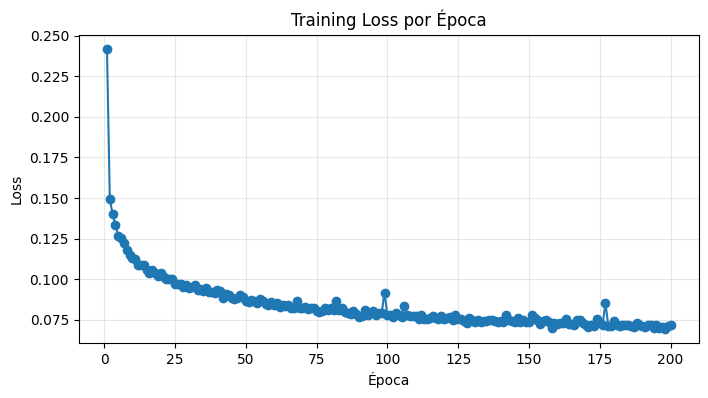

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs + 1), train_losses, marker="o")
plt.title("Training Loss por Época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.show()

In [25]:
model_torch.eval()

all_logits = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model_torch(X_batch).squeeze(1)
        all_logits.append(outputs)
        all_labels.append(y_batch)

logits = torch.cat(all_logits)
y_true_torch = torch.cat(all_labels)

probs = torch.sigmoid(logits)
y_pred_torch = (probs >= 0.5).float()

In [59]:
logits.shape, probs.shape, y_pred_torch.shape, y_true_torch.shape

(torch.Size([6517]),
 torch.Size([6517]),
 torch.Size([6517]),
 torch.Size([6517]))

In [26]:
y_true_np = y_true_torch.numpy()
y_pred_np = y_pred_torch.numpy()
probs_np = probs.numpy()

In [27]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_true_np, y_pred_np))
print("ROC-AUC:", roc_auc_score(y_true_np, probs_np))

              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98      5149
         1.0       0.98      0.87      0.92      1368

    accuracy                           0.97      6517
   macro avg       0.97      0.93      0.95      6517
weighted avg       0.97      0.97      0.97      6517

ROC-AUC: 0.9866464731129303


* Precision: cuando dice riesgo, casi siempre el modelo acierta
* Recall: Se escapan algunos defaults 12%
* f1 score: balance muy bueno

El modelo basado en PyTorch presenta un desempeño sobresaliente, alcanzando un ROC-AUC cercano a 0.99, lo que indica una alta capacidad de discriminación entre clientes en default y no default.

Si bien la precisión para la clase de riesgo es muy alta, el recall es ligeramente menor, lo que sugiere que el modelo es conservador al clasificar clientes como riesgosos.

La pérdida de entrenamiento converge de manera estable, aunque se observa que el modelo alcanza una meseta antes de las 500 épocas, lo que sugiere que un menor número de iteraciones podría ser suficiente para lograr un desempeño similar.

* sklearn ROC-AUC ≈ 0.968
* torch ROC-AUC ≈ 0.986

* PyTorch si mejora el baseline
* Modelo conservador pero confiable

## Pruebas de POO 

In [62]:
from src.credit_risk.models.torch_dataset import CreditRiskTorchDataset
from src.credit_risk.models.torch_model import (
    CreditRiskMLP,
    predict_torch_model,
    train_torch_model,
)

train_dataset = CreditRiskTorchDataset(X_train_tensor, y_train_tensor)
test_dataset = CreditRiskTorchDataset(X_test_tensor, y_test_tensor)

from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

input_dim = X_train_tensor.shape[1]
model_torch_modular = CreditRiskMLP(input_dim)

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_torch_modular.parameters(), lr=0.001)

train_losses = train_torch_model(
    model=model_torch_modular,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=20,
)

y_true_torch, probs_torch, y_pred_torch = predict_torch_model(
    model_torch_modular,
    test_loader,
)

y_true_np = y_true_torch.numpy()
probs_np = probs_torch.numpy()
y_pred_np = y_pred_torch.numpy()

Epoch [1/20] - Loss: 0.2335
Epoch [2/20] - Loss: 0.1486
Epoch [3/20] - Loss: 0.1382
Epoch [4/20] - Loss: 0.1312
Epoch [5/20] - Loss: 0.1257
Epoch [6/20] - Loss: 0.1221
Epoch [7/20] - Loss: 0.1190
Epoch [8/20] - Loss: 0.1167
Epoch [9/20] - Loss: 0.1158
Epoch [10/20] - Loss: 0.1139
Epoch [11/20] - Loss: 0.1130
Epoch [12/20] - Loss: 0.1102
Epoch [13/20] - Loss: 0.1094
Epoch [14/20] - Loss: 0.1087
Epoch [15/20] - Loss: 0.1055
Epoch [16/20] - Loss: 0.1065
Epoch [17/20] - Loss: 0.1045
Epoch [18/20] - Loss: 0.1031
Epoch [19/20] - Loss: 0.1030
Epoch [20/20] - Loss: 0.1050


In [63]:
# Validamos
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_true_np, y_pred_np))
print("ROC-AUC:", roc_auc_score(y_true_np, probs_np))

              precision    recall  f1-score   support

         0.0       0.96      0.99      0.98      5149
         1.0       0.96      0.85      0.90      1368

    accuracy                           0.96      6517
   macro avg       0.96      0.92      0.94      6517
weighted avg       0.96      0.96      0.96      6517

ROC-AUC: 0.986361826914668


#### Guardamos el modelo con 20 epocas


In [64]:
from src.credit_risk.models.torch_model import save_torch_model

save_torch_model(model_torch_modular, "models/torch_model.pt")

In [65]:
# Validamos que si se guardo

from pathlib import Path

Path("models/torch_model.pt").exists()

True

## Resultados del modelo

In [31]:
# Sacamos metricas de comparacion
from src.credit_risk.evaluation.metrics import summarize_metrics
from src.credit_risk.evaluation.results import ModelMetrics
from src.credit_risk.evaluation.compare import add_model_notes, build_model_comparison
from dataclasses import asdict


torch_results = summarize_metrics(y_true_np, y_pred_np, probs_np)
torch_metrics_obj = ModelMetrics(
    model_name="PyTorch MLP",
    precision_default=torch_results["precision_default"],
    recall_default=torch_results["recall_default"],
    f1_default=torch_results["f1_default"],
    roc_auc=torch_results["roc_auc"],
    notes="Modelo basado en red neuronal (MLP)",
)

results = {
    "PyTorch MLP": asdict(torch_metrics_obj),
}

comparison_df = build_model_comparison(results)

notes = {"PyTorch MLP": torch_metrics_obj.notes}

comparison_df = add_model_notes(comparison_df, notes)
comparison_df

,model,model_name,precision_default,recall_default,f1_default,roc_auc,notes
0,PyTorch MLP,PyTorch MLP,0.977068,0.872076,0.921591,0.986646,Modelo basado en red neuronal (MLP)


# Prueba de MLflow

In [69]:
from pathlib import Path

from src.credit_risk.tracking.mlflow_tracker import (
    log_metrics,
    log_params,
    log_torch_model_artifact,
    set_mlflow_experiment,
    set_tracking_uri,
    start_run,
)

PROJECT_ROOT = Path.cwd().resolve().parent
set_tracking_uri(PROJECT_ROOT / "mlruns")
set_mlflow_experiment("credit-risk-scoring")


with start_run(run_name="pytorch_mlp"):
    log_params(
        {
            "model_type": "pytorch_mlp",
            "input_dim": int(X_train_tensor.shape[1]),
            "batch_size": 64,
            "learning_rate": 0.001,
            "epochs": 20,
            "hidden_dim_1": 64,
            "hidden_dim_2": 32,
            "dropout": 0.2,
        }
    )

    log_metrics(torch_results)
    log_torch_model_artifact(
        PROJECT_ROOT / "notebooks" / "models" / "torch_model.pt", artifact_path="torch_model"
    )

Evidencia 
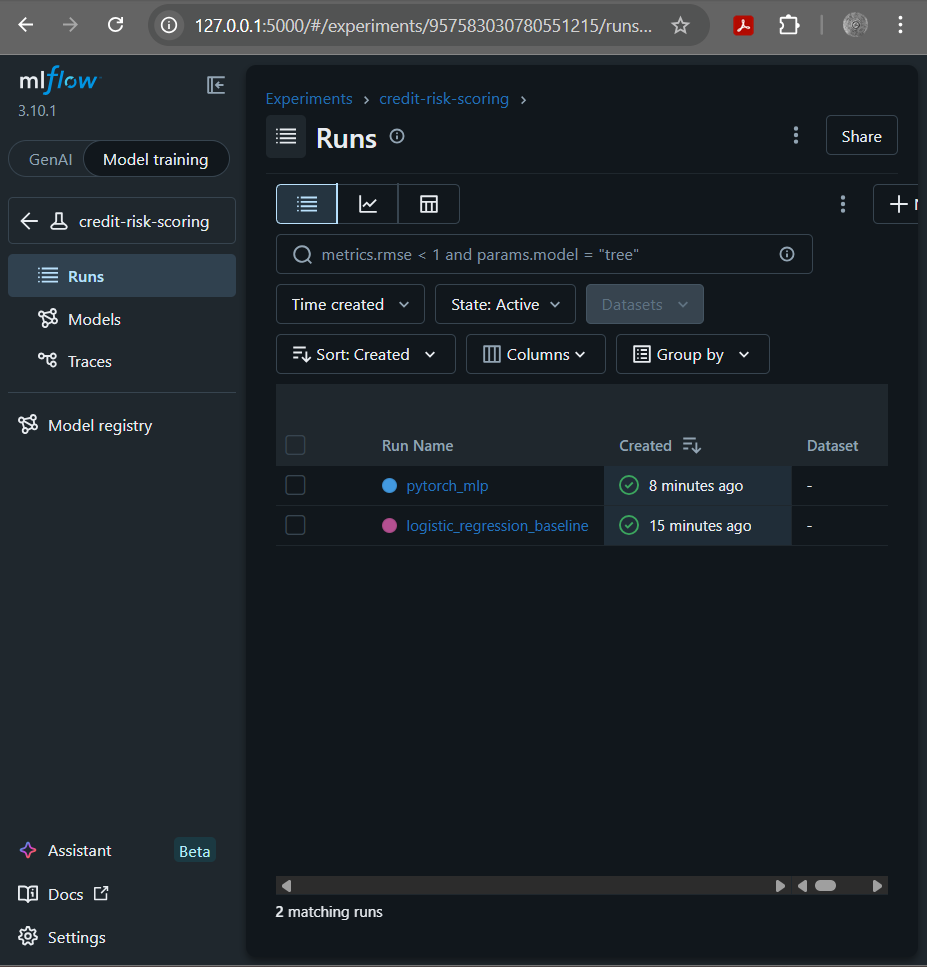

## Tracking de Experimentos con MLflow

Se utilizó MLflow para registrar los experimentos de entrenamiento de los modelos desarrollados en el proyecto.

Para cada run se almacenaron:
- parámetros relevantes del modelo,
- métricas de desempeño,
- y artefactos asociados, incluyendo el modelo de scikit-learn y el archivo serializado del modelo en PyTorch.

Esto permite comparar de forma estructurada los distintos enfoques probados, facilitando la trazabilidad y reproducibilidad del proceso de modelado.